# 1. Veri Yükleme ve Keşifsel Analiz

Bu notebook'ta yıldırım ve meteorolojik verileri yükleyip inceleyeceğiz.

**İçerik:**
- Kütüphanelerin yüklenmesi
- Yıldırım verisinin okunması
- Meteorolojik verilerin okunması
- Temel istatistikler
- Görselleştirmeler

In [1]:
# Gerekli Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Türkçe karakter desteği
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Kütüphaneler yüklendi!')

Kütüphaneler yüklendi!


## 1.1 Veri Yolu Tanımları

In [2]:
# Veri klasörü yolu
DATA_PATH = '../data/'

# Dosya listesi
dosyalar = os.listdir(DATA_PATH)
print("Veri klasöründeki dosyalar:")
for d in dosyalar:
    print(f"  - {d}")

Veri klasöründeki dosyalar:
  - 2025122218D3-Günlük Maksimum Rüzgar Yönü ve Hızı (m÷sn).xlsx
  - 2025122218D3-Günlük Maksimum Sıcaklık (°C).xlsx
  - 2025122218D3-Günlük Maksimum Yatay Görüş Mesafesi (km).xlsx
  - 2025122218D3-Günlük Minimum Sıcaklık (C).xlsx
  - 2025122218D3-Günlük Minimum Yatay Görüş Mesafesi (km).xlsx
  - 2025122218D3-Günlük Ortalama Aktüel Basınç (hPa).xlsx
  - 2025122218D3-Günlük Ortalama Bulutluluk (8 Okta).xlsx
  - 2025122218D3-Günlük Ortalama Nispi Nem (%).xlsx
  - 2025122218D3-Günlük Ortalama Rüzgar Hızı (m÷sn).xlsx
  - 2025122218D3-Günlük Ortalama Sıcaklık (°C).xlsx
  - 2025122218D3-Günlük Toplam Yağış (mm=kg÷m²) MANUEL.xlsx
  - 2025122218D3-Günlük Toplam Yağış (mm=kg÷m²) OMGİ .xlsx
  - 2025122218D3_Beni_Oku!!!.txt
  - 202601025EBE-Yıldırım_Tespit_Sistemi_05-02-2015_00-00_30-11-2025_23-59.txt


## 1.2 İstasyon Bilgileri

In [3]:
# İstasyon bilgileri
istasyonlar = pd.DataFrame({
    'istasyon_no': [17285, 17920, 18234, 18771, 17815, 19909],
    'istasyon_adi': ['HAKKARİ', 'YÜKSEKOVA', 'ŞEMDİNLİ', 'HAKKARİ/DURANKAYA', 
                    'YÜKSEKOVA HAVALİMANI', 'HAKKARİ KAYAK MERKEZİ'],
    'il': ['Hakkari'] * 6,
    'ilce': ['Merkez', 'Yüksekova', 'Şemdinli', 'Merkez', 'Yüksekova', 'Merkez'],
    'enlem': [37.5745, 37.5785, 37.2950, 37.56, 37.5481, 37.571393],
    'boylam': [43.7388, 44.2862, 44.5819, 43.6094, 44.2399, 43.6818],
    'rakim': [1727, 1877, 1284, 1825, 1854, 2516]
})

print("İstasyon Bilgileri:")
display(istasyonlar)

İstasyon Bilgileri:


,istasyon_no,istasyon_adi,il,ilce,enlem,boylam,rakim
0,17285,HAKKARİ,Hakkari,Merkez,37.574500,43.7388,1727
1,17920,YÜKSEKOVA,Hakkari,Yüksekova,37.578500,44.2862,1877
2,18234,ŞEMDİNLİ,Hakkari,Şemdinli,37.295000,44.5819,1284
3,18771,HAKKARİ/DURANKAYA,Hakkari,Merkez,37.560000,43.6094,1825
4,17815,YÜKSEKOVA HAVALİMANI,Hakkari,Yüksekova,37.548100,44.2399,1854
5,19909,HAKKARİ KAYAK MERKEZİ,Hakkari,Merkez,37.571393,43.6818,2516


## 1.3 Yıldırım Verisinin Yüklenmesi

In [4]:
# Yıldırım verisi dosya adı
yildirim_dosya = [f for f in dosyalar if 'Yıldırım' in f or 'Y?ld?r?m' in f][0]
print(f"Yıldırım dosyası: {yildirim_dosya}")

# Veriyi oku
yildirim_df = pd.read_csv(
    DATA_PATH + yildirim_dosya,
    sep='|',
    encoding='latin-1',
    header=0
)

# Sütun isimlerini düzenle
yildirim_df.columns = ['zaman', 'enlem', 'boylam', 'yukseklik_km', 'akim_kA', 'olay_tipi', 'mesafe_km']

print(f"\nToplam kayıt sayısı: {len(yildirim_df):,}")
print(f"\nİlk 5 satır:")
display(yildirim_df.head())

Yıldırım dosyası: 202601025EBE-Yıldırım_Tespit_Sistemi_05-02-2015_00-00_30-11-2025_23-59.txt

Toplam kayıt sayısı: 258,815

İlk 5 satır:


,zaman,enlem,boylam,yukseklik_km,akim_kA,olay_tipi,mesafe_km
0,2015-02-06 12:10:40.996,37.5311,43.4606,0,-6,?im?ek,35.5
1,2015-02-10 14:16:45.115,37.6301,43.7324,0,-13,Y?ld?r?m,28.0
2,2015-02-10 08:06:15.482,37.4589,44.3440,0,31,Y?ld?r?m,46.6
3,2015-02-10 13:31:59.976,37.5928,44.0626,0,-56,Y?ld?r?m,31.1
4,2015-02-10 07:25:20.560,37.1182,44.0328,0,-30,Y?ld?r?m,35.2


In [5]:
# Zaman sütununu datetime'a çevir
yildirim_df['zaman'] = pd.to_datetime(yildirim_df['zaman'], format='%Y-%m-%d %H:%M:%S.%f')
yildirim_df['tarih'] = yildirim_df['zaman'].dt.date
yildirim_df['yil'] = yildirim_df['zaman'].dt.year
yildirim_df['ay'] = yildirim_df['zaman'].dt.month
yildirim_df['gun'] = yildirim_df['zaman'].dt.day
yildirim_df['saat'] = yildirim_df['zaman'].dt.hour

print("Veri tipi dönüşümü tamamlandı!")
print(f"\nTarih aralığı: {yildirim_df['tarih'].min()} - {yildirim_df['tarih'].max()}")

Veri tipi dönüşümü tamamlandı!

Tarih aralığı: 2015-02-06 - 2025-11-16


In [6]:
# Olay tipi dağılımı
print("Olay Tipi Dağılımı:")
print(yildirim_df['olay_tipi'].value_counts())

Olay Tipi Dağılımı:
olay_tipi
Y?ld?r?m    216178
?im?ek       42637
Name: count, dtype: int64


In [7]:
# Temel istatistikler
print("Sayısal Değişkenler için İstatistikler:")
display(yildirim_df[['enlem', 'boylam', 'yukseklik_km', 'akim_kA', 'mesafe_km']].describe())

Sayısal Değişkenler için İstatistikler:


,enlem,boylam,yukseklik_km,akim_kA,mesafe_km
count,258815.000000,258815.000000,258815.000000,258815.000000,258815.000000
mean,37.373738,43.776671,1.778502,-7.125178,32.907830
std,0.212745,0.292133,4.586592,19.544918,12.401559
min,36.938000,43.254300,0.000000,-301.000000,0.000000
25%,37.218000,43.531900,0.000000,-14.000000,24.000000
50%,37.373700,43.772100,0.000000,-10.000000,35.600000
75%,37.524700,44.009700,0.000000,-6.000000,43.600000
max,37.837700,44.389100,30.000000,279.000000,49.900000


## 1.4 Yıldırım Verisi Görselleştirmeleri

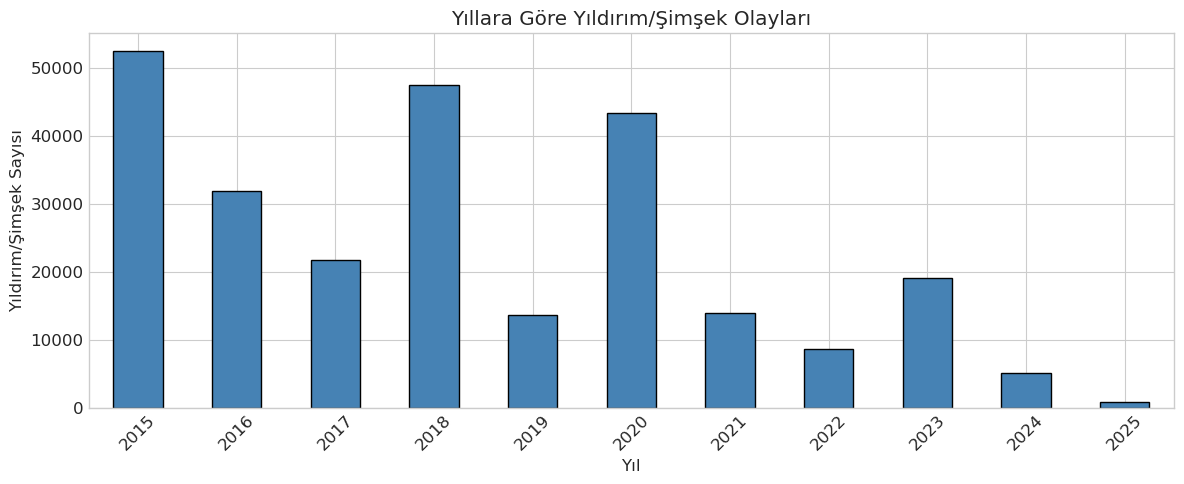

In [8]:
# Yıllık yıldırım sayısı
fig, ax = plt.subplots(figsize=(12, 5))
yillik_sayi = yildirim_df.groupby('yil').size()
yillik_sayi.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Yıl')
ax.set_ylabel('Yıldırım/Şimşek Sayısı')
ax.set_title('Yıllara Göre Yıldırım/Şimşek Olayları')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../tez_docs/figures/yillik_yildirim.png', dpi=150)
plt.show()

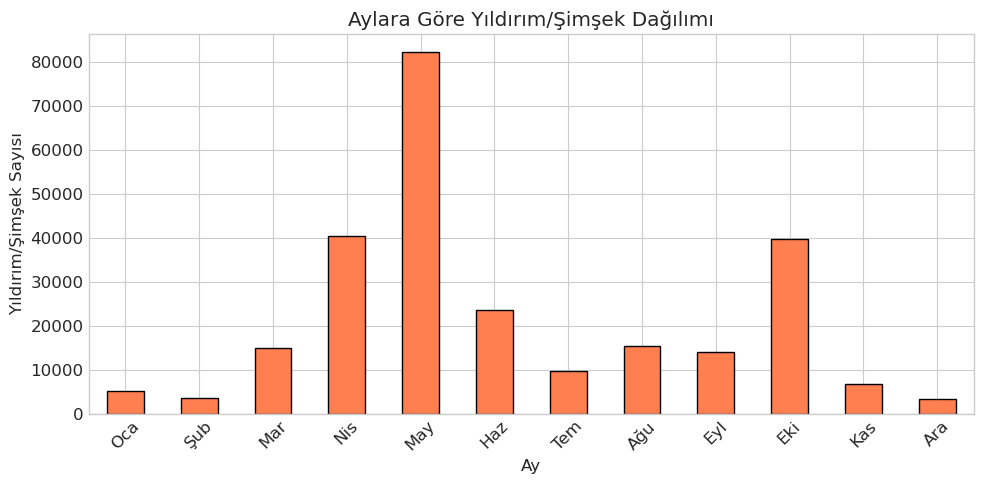

In [9]:
# Aylık dağılım
fig, ax = plt.subplots(figsize=(10, 5))
aylik_sayi = yildirim_df.groupby('ay').size()
ay_isimleri = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz', 'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
aylik_sayi.index = ay_isimleri
aylik_sayi.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Ay')
ax.set_ylabel('Yıldırım/Şimşek Sayısı')
ax.set_title('Aylara Göre Yıldırım/Şimşek Dağılımı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../tez_docs/figures/aylik_yildirim.png', dpi=150)
plt.show()

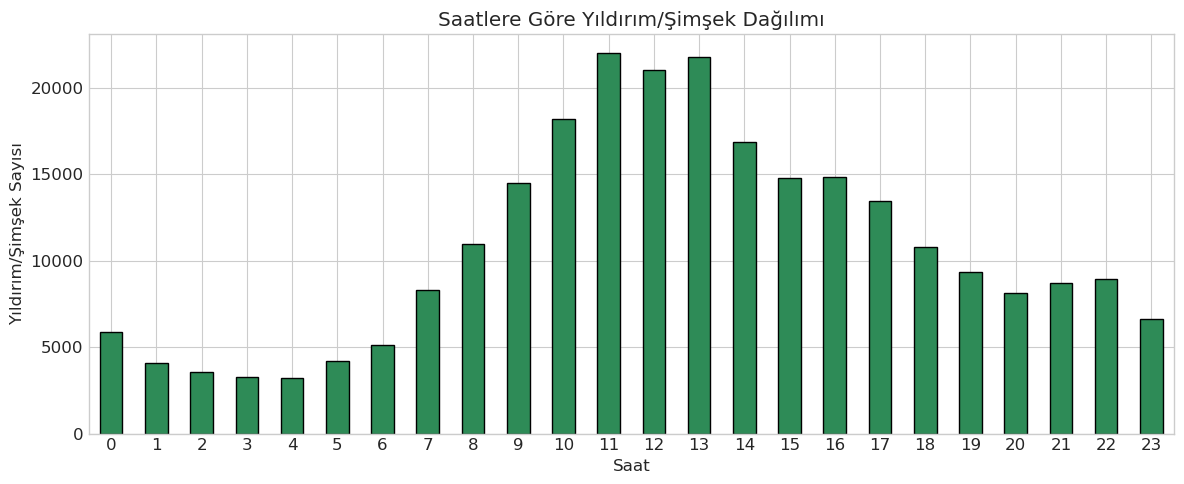

In [10]:
# Saatlik dağılım
fig, ax = plt.subplots(figsize=(12, 5))
saatlik_sayi = yildirim_df.groupby('saat').size()
saatlik_sayi.plot(kind='bar', ax=ax, color='seagreen', edgecolor='black')
ax.set_xlabel('Saat')
ax.set_ylabel('Yıldırım/Şimşek Sayısı')
ax.set_title('Saatlere Göre Yıldırım/Şimşek Dağılımı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../tez_docs/figures/saatlik_yildirim.png', dpi=150)
plt.show()

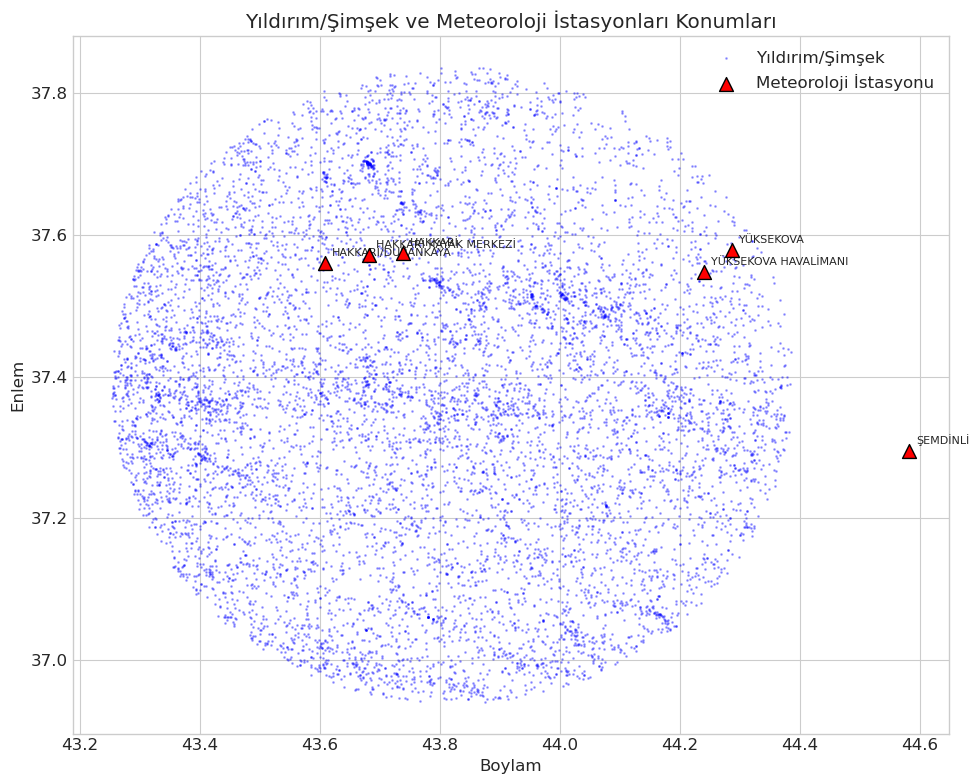

In [11]:
# Coğrafi dağılım
fig, ax = plt.subplots(figsize=(10, 8))

# Yıldırım noktaları (örnek - tümünü çizmek yavaş olabilir)
sample = yildirim_df.sample(min(10000, len(yildirim_df)))
ax.scatter(sample['boylam'], sample['enlem'], alpha=0.3, s=1, c='blue', label='Yıldırım/Şimşek')

# İstasyon konumları
ax.scatter(istasyonlar['boylam'], istasyonlar['enlem'], c='red', s=100, marker='^', 
           edgecolors='black', label='Meteoroloji İstasyonu', zorder=5)

for idx, row in istasyonlar.iterrows():
    ax.annotate(row['istasyon_adi'], (row['boylam'], row['enlem']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Boylam')
ax.set_ylabel('Enlem')
ax.set_title('Yıldırım/Şimşek ve Meteoroloji İstasyonları Konumları')
ax.legend()
plt.tight_layout()
plt.savefig('../tez_docs/figures/cografi_dagilim.png', dpi=150)
plt.show()

## 1.5 Meteorolojik Verilerin Yüklenmesi

In [12]:
def yukle_meteoroloji(dosya_adi, veri_adi):
    """Meteorolojik Excel dosyasını yükler ve düzenler."""
    try:
        df = pd.read_excel(DATA_PATH + dosya_adi)
        print(f"{veri_adi}: {df.shape[0]} satır, {df.shape[1]} sütun")
        return df
    except Exception as e:
        print(f"Hata ({veri_adi}): {e}")
        return None

# Meteorolojik verileri yükle
meteo_dosyalar = {
    'maks_sicaklik': [f for f in dosyalar if 'Maksimum Sıcaklık' in f or 'Maksimum S?cakl?k' in f][0],
    'min_sicaklik': [f for f in dosyalar if 'Minimum Sıcaklık' in f or 'Minimum S?cakl?k' in f][0],
    'ort_sicaklik': [f for f in dosyalar if 'Ortalama Sıcaklık' in f or 'Ortalama S?cakl?k' in f][0],
    'basinc': [f for f in dosyalar if 'Basınç' in f or 'Bas?n?' in f][0],
    'nem': [f for f in dosyalar if 'Nem' in f][0],
    'bulut': [f for f in dosyalar if 'Bulutluluk' in f][0],
    'ruzgar': [f for f in dosyalar if 'Rüzgar' in f or 'R?zgar' in f][0],
}

# Yağış dosyaları
yagis_dosyalari = [f for f in dosyalar if 'Yağış' in f or 'Ya???' in f]
if yagis_dosyalari:
    meteo_dosyalar['yagis'] = yagis_dosyalari[0]

print("Yüklenecek dosyalar:")
for k, v in meteo_dosyalar.items():
    print(f"  {k}: {v}")

Yüklenecek dosyalar:
  maks_sicaklik: 2025122218D3-Günlük Maksimum Sıcaklık (°C).xlsx
  min_sicaklik: 2025122218D3-Günlük Minimum Sıcaklık (C).xlsx
  ort_sicaklik: 2025122218D3-Günlük Ortalama Sıcaklık (°C).xlsx
  basinc: 2025122218D3-Günlük Ortalama Aktüel Basınç (hPa).xlsx
  nem: 2025122218D3-Günlük Ortalama Nispi Nem (%).xlsx
  bulut: 2025122218D3-Günlük Ortalama Bulutluluk (8 Okta).xlsx
  ruzgar: 2025122218D3-Günlük Maksimum Rüzgar Yönü ve Hızı (m÷sn).xlsx
  yagis: 2025122218D3-Günlük Toplam Yağış (mm=kg÷m²) MANUEL.xlsx


In [13]:
# Tüm meteorolojik verileri yükle
meteo_veriler = {}

for veri_adi, dosya in meteo_dosyalar.items():
    meteo_veriler[veri_adi] = yukle_meteoroloji(dosya, veri_adi)

maks_sicaklik: 19032 satır, 6 sütun
min_sicaklik: 19037 satır, 6 sütun
ort_sicaklik: 20200 satır, 6 sütun
basinc: 14432 satır, 6 sütun
nem: 20167 satır, 6 sütun
bulut: 7540 satır, 6 sütun
ruzgar: 17032 satır, 6 sütun
yagis: 7840 satır, 6 sütun


In [14]:
# Örnek: Maksimum sıcaklık verisinin ilk satırları
if meteo_veriler['maks_sicaklik'] is not None:
    print("\nMaksimum Sıcaklık Verisi (İlk 5 satır):")
    display(meteo_veriler['maks_sicaklik'].head())


Maksimum Sıcaklık Verisi (İlk 5 satır):


,Istasyon_No,Istasyon_Adi,YIL,AY,GUN,MAKSIMUM_SICAKLIK_°C
0,17285,HAKKARİ,2015.0,3.0,1.0,8.6
1,17285,HAKKARİ,2015.0,3.0,2.0,5.4
2,17285,HAKKARİ,2015.0,3.0,3.0,6.7
3,17285,HAKKARİ,2015.0,3.0,4.0,7.2
4,17285,HAKKARİ,2015.0,3.0,5.0,5.4


In [15]:
# Eksik veri analizi
print("\nEksik Veri Analizi:")
for veri_adi, df in meteo_veriler.items():
    if df is not None:
        eksik_oran = (df.isnull().sum().sum() / df.size) * 100
        print(f"  {veri_adi}: %{eksik_oran:.2f} eksik")


Eksik Veri Analizi:
  maks_sicaklik: %0.00 eksik
  min_sicaklik: %0.00 eksik
  ort_sicaklik: %0.00 eksik
  basinc: %0.01 eksik
  nem: %0.00 eksik
  bulut: %0.01 eksik
  ruzgar: %0.00 eksik
  yagis: %14.46 eksik


## 1.6 Günlük Yıldırım Sayıları

In [16]:
# Günlük yıldırım sayısı
gunluk_yildirim = yildirim_df.groupby('tarih').size().reset_index(name='yildirim_sayisi')
gunluk_yildirim['tarih'] = pd.to_datetime(gunluk_yildirim['tarih'])

print(f"Yıldırım olan gün sayısı: {len(gunluk_yildirim)}")
print(f"\nGünlük yıldırım sayısı istatistikleri:")
display(gunluk_yildirim['yildirim_sayisi'].describe())

Yıldırım olan gün sayısı: 1006

Günlük yıldırım sayısı istatistikleri:


count    1006.000000
mean      257.271372
std       684.954676
min         1.000000
25%         6.000000
50%        34.000000
75%       177.500000
max      7526.000000
Name: yildirim_sayisi, dtype: float64

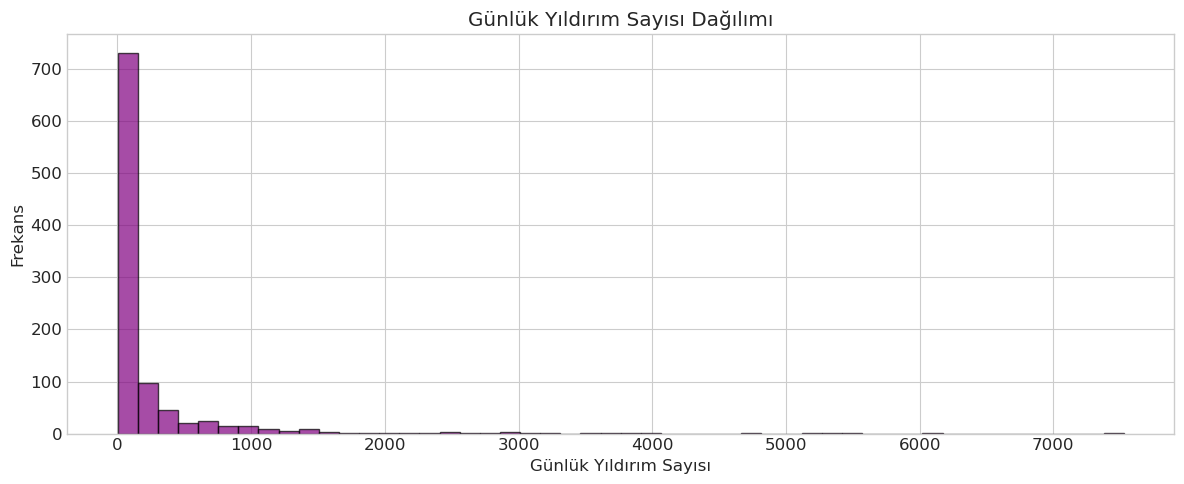

In [17]:
# Günlük yıldırım sayısı dağılımı
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(gunluk_yildirim['yildirim_sayisi'], bins=50, color='purple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Günlük Yıldırım Sayısı')
ax.set_ylabel('Frekans')
ax.set_title('Günlük Yıldırım Sayısı Dağılımı')
plt.tight_layout()
plt.savefig('../tez_docs/figures/gunluk_yildirim_dagilim.png', dpi=150)
plt.show()

## 1.7 Verilerin Kaydedilmesi

In [18]:
# Ara verileri kaydet
yildirim_df.to_pickle('../data/yildirim_processed.pkl')
gunluk_yildirim.to_pickle('../data/gunluk_yildirim.pkl')
istasyonlar.to_pickle('../data/istasyonlar.pkl')

for veri_adi, df in meteo_veriler.items():
    if df is not None:
        df.to_pickle(f'../data/meteo_{veri_adi}.pkl')

print("Veriler kaydedildi!")

Veriler kaydedildi!


---
**Sonraki Adım:** `02_veri_onisleme.ipynb` - Veri Birleştirme ve Temizleme